# Panel cumulative local projections: CPI on xi x oil with toggleable extra oil2 regressor (euro sample)

This notebook estimates cumulative panel local projections using quarterly CPI inflation for the euro sample, keeping only observations from each country's euro-adoption quarter onward.

The extra regressor can be toggled between plain `oil2` and `zeta_x_oil2`.

Conventions used here:

- the dependent variable at horizon `h` is the cumulative sum of quarterly CPI inflation from `t` through `t+h`,
- lags of `y` are lags of the underlying quarterly CPI inflation series, not lags of the cumulative target,
- if enabled, annual CPI can replace the cumulative quarterly target only for full calendar-year windows.


In [54]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp
from io_networks.policy_rates import EURO_ADOPTION_STARTS


In [55]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
annual_cpi_path = ROOT / "data/processed/cpi/annual_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

zeta_path = ROOT / "data/processed/zeta/regular/zeta_by_country_year.parquet"
oil2_col = "oil2"
zeta_x_oil2_col = "oil2"
extra_regressor_mode = "oil2"  # options: "zeta_x_oil2", "oil2"
if extra_regressor_mode == "zeta_x_oil2":
    extra_regressor_col = zeta_x_oil2_col
elif extra_regressor_mode == "oil2":
    extra_regressor_col = oil2_col
else:
    raise ValueError("extra_regressor_mode must be 'zeta_x_oil2' or 'oil2'.")

base_regression_controls = ["output_gap", "exchange_rate", "policy_rate"] # ["exchange_rate", "output_gap", "policy_rate"]
regression_controls = base_regression_controls.copy()

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    }
]

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"exchange_rate": 3, "output_gap": 3, "policy_rate": 3}
include_country_fe = True
include_time_fe = False
cov_type = "cluster_country_time"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = 1999
sample_end = None
use_annual_cpi_for_full_year_horizons = False
lag_xi_by_one_year_for_xi_x_oil = True
lag_zeta_by_one_year_for_zeta_x_oil2 = True
shock_cols = ["xi_x_oil", extra_regressor_col]
shock_labels = {
    "xi_x_oil": "xi_x_oil",
    oil2_col: oil2_col,
    zeta_x_oil2_col: zeta_x_oil2_col,
}

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("include_country_fe:", include_country_fe)
print("include_time_fe:", include_time_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("base_regression_controls:", base_regression_controls)
print("regression_controls:", regression_controls)
print("control_lags:", control_lags)
print("extra_regressor_mode:", extra_regressor_mode)
print("extra_regressor_col:", extra_regressor_col)
print("shock_cols:", shock_cols)
print("use_annual_cpi_for_full_year_horizons:", use_annual_cpi_for_full_year_horizons)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)
print("lag_zeta_by_one_year_for_zeta_x_oil2:", lag_zeta_by_one_year_for_zeta_x_oil2)


horizons: 11
y_lags: 3
shock_lags: 3
include_country_fe: True
include_time_fe: False
cov_type: cluster_country_time
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate']
base_regression_controls: ['output_gap', 'exchange_rate', 'policy_rate']
regression_controls: ['output_gap', 'exchange_rate', 'policy_rate']
control_lags: {'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
extra_regressor_mode: oil2
extra_regressor_col: oil2
shock_cols: ['xi_x_oil', 'oil2']
use_annual_cpi_for_full_year_horizons: False
lag_xi_by_one_year_for_xi_x_oil: True
lag_zeta_by_one_year_for_zeta_x_oil2: True


In [56]:
def load_annual_cpi(path: Path) -> pd.DataFrame:
    annual = lp.regression.load_cpi_pct_change(path, freq="A")
    annual = annual.rename(columns={"cpi_pct_change": "annual_cpi_pct_change"})
    return annual


def add_cumulative_targets(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    horizons: int = 8,
    annual_cpi_df: pd.DataFrame | None = None,
    use_annual_override: bool = False,
) -> pd.DataFrame:
    out = df.copy().sort_values(["country", "time_index"]).reset_index(drop=True)
    if "period" not in out.columns:
        raise ValueError("Quarterly cumulative LP requires a 'period' column.")

    period_parts = out["period"].astype(str).str.extract(r"^(\d{4})-Q([1-4])$")
    out["period_year"] = pd.to_numeric(period_parts[0], errors="coerce")
    out["period_quarter"] = pd.to_numeric(period_parts[1], errors="coerce")
    if out[["period_year", "period_quarter"]].isna().any().any():
        raise ValueError("Could not parse year/quarter from the quarterly period labels.")
    out["period_year"] = out["period_year"].astype(int)
    out["period_quarter"] = out["period_quarter"].astype(int)

    if annual_cpi_df is not None:
        annual_lookup = annual_cpi_df.copy()
    else:
        annual_lookup = None

    for horizon in range(horizons + 1):
        target_col = f"cum_cpi_lead{horizon}"
        out[target_col] = 0.0
        for step in range(horizon + 1):
            shifted = out.groupby("country")[y_col].shift(-step)
            out[target_col] = shifted if step == 0 else out[target_col] + shifted

        if use_annual_override and annual_lookup is not None and (horizon + 1) % 4 == 0:
            end_year_col = f"end_year_h{horizon}"
            end_quarter_col = f"end_quarter_h{horizon}"
            out[end_year_col] = out.groupby("country")["period_year"].shift(-horizon)
            out[end_quarter_col] = out.groupby("country")["period_quarter"].shift(-horizon)
            aligned = (out["period_quarter"] == 1) & (out[end_quarter_col] == 4)
            annual_rows = []
            years_in_window = (horizon + 1) // 4
            for year_offset in range(years_in_window):
                year_col = f"annual_year_h{horizon}_{year_offset}"
                value_col = f"annual_cpi_h{horizon}_{year_offset}"
                out[year_col] = out["period_year"] + year_offset
                merged = out[["country", year_col]].merge(
                    annual_lookup,
                    left_on=["country", year_col],
                    right_on=["country", "year"],
                    how="left",
                )
                out[value_col] = merged["annual_cpi_pct_change"].values
                annual_rows.append(value_col)
            annual_sum = out[annual_rows].sum(axis=1, min_count=years_in_window)
            out[target_col] = out[target_col].where(~aligned, annual_sum)

    return out


def fit_cumulative_panel_local_projections(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    shock_col: str = "xi_x_oil",
    horizons: int = 8,
    y_lags: int = 4,
    shock_lags: int = 0,
    controls: list[str] | None = None,
    control_lags: int | dict[str, int] = 0,
    include_country_fe: bool = True,
    include_time_fe: bool = True,
    cov_type: str = "cluster_country",
) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, object]]:
    controls = controls or []
    required = {"country", "time_index", y_col, shock_col, *controls}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing cumulative LP columns: {sorted(missing)}")

    target_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
    missing_targets = sorted(set(target_cols) - set(df.columns))
    if missing_targets:
        raise ValueError(f"Missing cumulative target columns: {missing_targets}")

    work = df[["country", "time_index", "year", "period", y_col, shock_col, *controls, *target_cols]].copy()
    work = work.sort_values(["country", "time_index"]).reset_index(drop=True)

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"{y_col}_lag{lag}"
        work[col] = work.groupby("country")[y_col].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    for lag in range(1, shock_lags + 1):
        col = f"{shock_col}_lag{lag}"
        work[col] = work.groupby("country")[shock_col].shift(lag)
        shock_lag_cols.append(col)

    control_cols = []
    for control in controls:
        #control_cols.append(control)
        lag_count = control_lags[control] if isinstance(control_lags, dict) else int(control_lags)
        for lag in range(1, lag_count + 1):
            col = f"{control}_lag{lag}"
            work[col] = work.groupby("country")[control].shift(lag)
            control_cols.append(col)

    irf_rows = []
    coef_rows = []
    models = {}

    for horizon in range(horizons + 1):
        dep_col = f"cum_cpi_lead{horizon}"

        x_cols = [shock_col, *shock_lag_cols, *y_lag_cols, *control_cols]
        x_base = work[x_cols].copy()
        fe_cols = []

        if include_country_fe:
            country_fe = pd.get_dummies(work["country"], prefix="country_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, country_fe], axis=1)
            fe_cols.extend(country_fe.columns.tolist())

        if include_time_fe:
            time_fe = pd.get_dummies(work["time_index"], prefix="time_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, time_fe], axis=1)
            fe_cols.extend(time_fe.columns.tolist())

        design = pd.concat([work[["country", "year", "period", dep_col]], x_base], axis=1).dropna().reset_index(drop=True)
        if design.empty:
            raise ValueError(
                "No rows left for cumulative local projections after target, lag, and missing-data filters. "
                f"horizon={horizon}, y_lags={y_lags}, shock_lags={shock_lags}."
            )

        y = pd.to_numeric(design[dep_col], errors="coerce")
        x = sm.add_constant(design[x_cols + fe_cols], has_constant="add")
        base_model = sm.OLS(y, x, missing="raise")
        if cov_type == "cluster_country":
            model = base_model.fit(cov_type="cluster", cov_kwds={"groups": design["country"]})
            std_err_col = "std_err_cluster_country"
        elif cov_type == "hc3":
            model = base_model.fit(cov_type="HC3")
            std_err_col = "std_err_hc3"
        else:
            raise ValueError(f"Unsupported cov_type '{cov_type}'.")

        models[horizon] = model
        ci = model.conf_int()
        coef_df = pd.DataFrame(
            {
                "horizon": horizon,
                "term": model.params.index,
                "coef": model.params.values,
                std_err_col: model.bse.values,
                "t": model.tvalues.values,
                "p_value": model.pvalues.values,
                "ci_low_95": ci.iloc[:, 0].values,
                "ci_high_95": ci.iloc[:, 1].values,
                "nobs": float(model.nobs),
            }
        )
        coef_rows.extend(coef_df.to_dict(orient="records"))

        shock_row = coef_df.loc[coef_df["term"] == shock_col]
        irf_rows.append(
            {
                "horizon": horizon,
                "term": shock_col,
                "coef": float(shock_row["coef"].iloc[0]),
                std_err_col: float(shock_row[std_err_col].iloc[0]),
                "t": float(shock_row["t"].iloc[0]),
                "p_value": float(shock_row["p_value"].iloc[0]),
                "ci_low_95": float(shock_row["ci_low_95"].iloc[0]),
                "ci_high_95": float(shock_row["ci_high_95"].iloc[0]),
                "nobs": float(model.nobs),
                "n_countries": int(design["country"].nunique()),
            }
        )

    return pd.DataFrame(irf_rows), pd.DataFrame(coef_rows), models


In [57]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

euro_start = (
    pd.Series(EURO_ADOPTION_STARTS, name="euro_start")
    .rename_axis("country")
    .reset_index()
)
euro_start["euro_start"] = pd.PeriodIndex(euro_start["euro_start"], freq="Q")

panel_df = panel_df.copy()
panel_df["period_q"] = pd.PeriodIndex(panel_df["period"].astype(str), freq="Q")

panel_df = (
    panel_df.merge(euro_start, on="country", how="inner")
    .loc[lambda d: d["period_q"] >= d["euro_start"]]
    .drop(columns=["period_q", "euro_start"])
    .sort_values(["country", "time_index"])
    .reset_index(drop=True)
)

if extra_regressor_mode == "zeta_x_oil2":
    zeta_df = pd.read_parquet(zeta_path)
    zeta_df = zeta_df.loc[zeta_df["status"] == "ok", ["country", "year", "zeta"]].copy()
    zeta_df["year"] = pd.to_numeric(zeta_df["year"], errors="coerce")
    zeta_df["zeta"] = pd.to_numeric(zeta_df["zeta"], errors="coerce")
    zeta_df = zeta_df.dropna(subset=["country", "year", "zeta"])
    zeta_df["year"] = zeta_df["year"].astype(int)
    zeta_df = zeta_df.sort_values(["country", "year"]).reset_index(drop=True)
    if lag_zeta_by_one_year_for_zeta_x_oil2:
        zeta_df["zeta_for_interactions"] = zeta_df.groupby("country")["zeta"].shift(1)
    else:
        zeta_df["zeta_for_interactions"] = zeta_df["zeta"]

    panel_df = panel_df.merge(
        zeta_df[["country", "year", "zeta", "zeta_for_interactions"]],
        on=["country", "year"],
        how="left",
        validate="many_to_one",
    )
else:
    panel_df["zeta"] = pd.NA
    panel_df["zeta_for_interactions"] = pd.NA

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,1476,19,1999,2022,19.421053,1999-Q1,2022-Q4,77.684211


In [58]:
panel_df_model = panel_df.copy()
panel_df_model[oil2_col] = panel_df_model["oil_pct_change"] ** 2
if extra_regressor_mode == "zeta_x_oil2":
    panel_df_model[zeta_x_oil2_col] = panel_df_model["zeta_for_interactions"] * panel_df_model[oil2_col]

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

annual_cpi_df = load_annual_cpi(annual_cpi_path)
panel_df_model = lp.build_cumulative_targets(
    panel_df_model,
    y_col="cpi_pct_change",
    horizons=horizons,
    annual_cpi_df=annual_cpi_df,
    use_annual_override=use_annual_cpi_for_full_year_horizons,
)

display_cols = ["country", "period", "oil_pct_change", oil2_col, "xi_x_oil"]
if extra_regressor_mode == "zeta_x_oil2":
    display_cols = ["country", "period", "zeta", "zeta_for_interactions", "oil_pct_change", oil2_col, zeta_x_oil2_col, "xi_x_oil"]

panel_df_model[display_cols].head()


CPI outlier filter disabled.
Rows kept: 1476


,country,period,oil_pct_change,oil2,xi_x_oil
0,AUT,1999-Q1,-0.004137,0.000017,-0.000078
1,AUT,1999-Q2,0.315823,0.099744,0.005983
2,AUT,1999-Q3,0.245995,0.060514,0.004661
3,AUT,1999-Q4,0.140305,0.019685,0.002658
4,AUT,2000-Q1,0.117547,0.013817,0.002283


In [59]:
pairwise_corr = panel_df_model[shock_cols].corr()
pairwise_corr


,xi_x_oil,oil2
xi_x_oil,1.000000,-0.448895
oil2,-0.448895,1.000000


In [60]:
irf_df, coef_df, models = lp.fit_cumulative_panel_local_projections_multi(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_cols=shock_cols,
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_time_fe=include_time_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

plot_title = f"Cumulative panel local projections (euro sample): joint CPI response to xi_x_oil and {extra_regressor_col}"

irf_df


,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,0.472552,0.073907,6.393895,1.617122e-10,0.327697,0.617407,1210.0,19
1,0,oil2,0.001843,0.004396,0.419386,6.749341e-01,-0.006772,0.010459,1210.0,19
2,1,xi_x_oil,0.599604,0.111798,5.363290,8.171969e-08,0.380484,0.818723,1210.0,19
3,1,oil2,-0.014504,0.009650,-1.502974,1.328458e-01,-0.033418,0.004410,1210.0,19
4,2,xi_x_oil,0.667253,0.150888,4.422187,9.770663e-06,0.371519,0.962987,1210.0,19
5,2,oil2,-0.017023,0.013454,-1.265276,2.057725e-01,-0.043393,0.009346,1210.0,19
6,3,xi_x_oil,0.782117,0.201698,3.877660,1.054659e-04,0.386796,1.177438,1210.0,19
7,3,oil2,-0.020378,0.017364,-1.173591,2.405588e-01,-0.054410,0.013654,1210.0,19
8,4,xi_x_oil,0.908319,0.236249,3.844756,1.206727e-04,0.445280,1.371359,1210.0,19
9,4,oil2,-0.020536,0.019174,-1.071033,2.841545e-01,-0.058116,0.017044,1210.0,19


In [61]:
from cycler import cycler
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Georgia", "Garamond", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "axes.titlesize": 18,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "text.color": "#000000",
    "axes.labelcolor": "#000000",
    "axes.edgecolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "axes.prop_cycle": cycler(color=[
        "#324152",  # main line
    ]),
})

naming = "heterogeneity" if include_time_fe else "baseline"

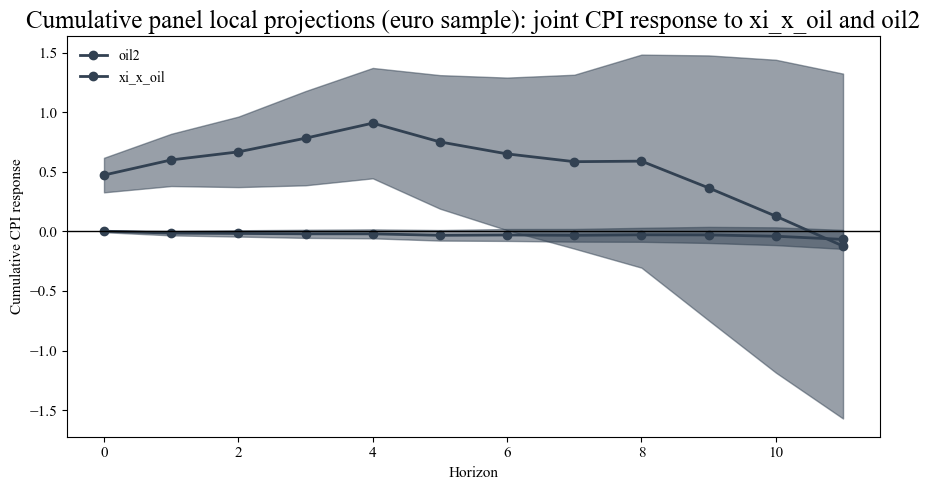

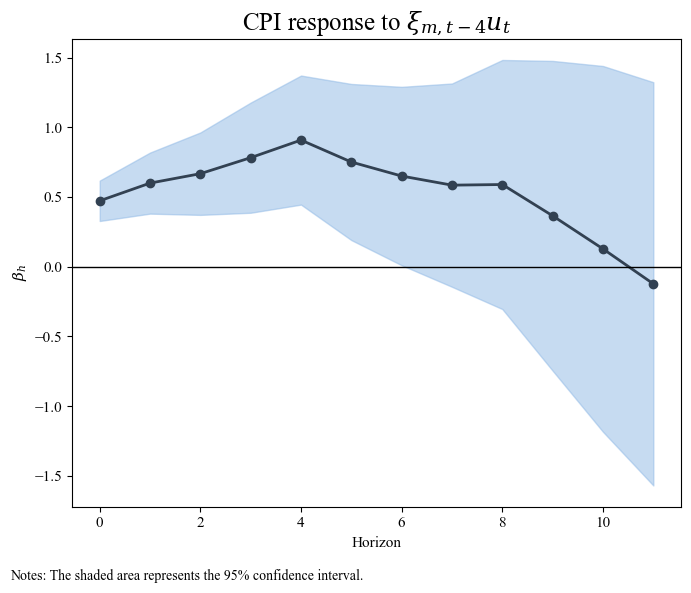

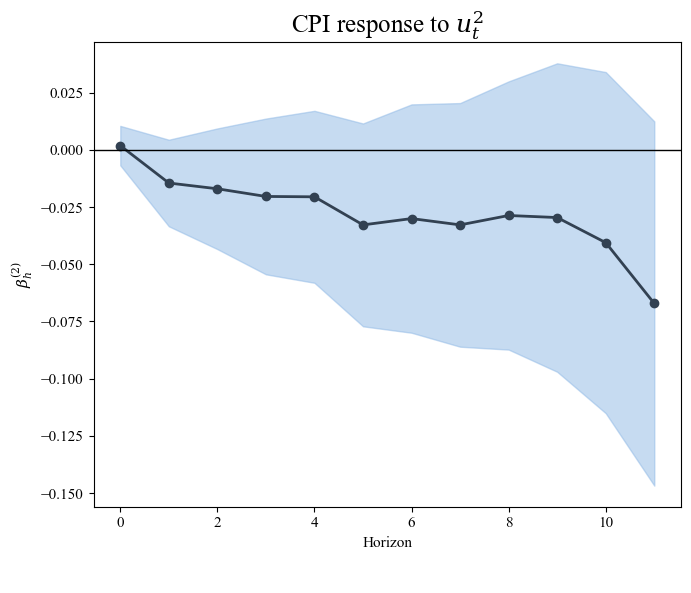

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
lp.plot_irf_multi(
    irf_df,
    title=plot_title,
    term_labels={term: shock_labels[term] for term in shock_cols},
    ax=ax,
)
ax.set_ylabel("Cumulative CPI response")

plt.tight_layout()
plt.show()

separate_plot_settings = {
    "xi_x_oil": {
        "title": r"CPI response to $\xi_{m,t-4}u_t$",
        "x_label": "Horizon",
        "y_label": r"$\beta_h$",
        "fig_text": r"Notes: The shaded area represents the 95% confidence interval.",
        "figsize": (7, 6),
    },
    extra_regressor_col: {
        "title": r"CPI response to $u_t^2$",
        "x_label": "Horizon",
        "y_label": r"$\beta_h^{(2)}$",
        "fig_text": " ",
        "figsize": (7, 6),
    },
}

for term in shock_cols:
    settings = separate_plot_settings.get(term, {})
    fig, ax = plt.subplots(figsize=settings.get("figsize", (7, 6)))
    lp.plot_irf(
        irf_df.loc[irf_df["term"] == term].copy(),
        title=settings.get("title", f"Response to {term}"),
        ax=ax,
    )
    ax.set_xlabel(settings.get("x_label", "Horizon"))
    ax.set_ylabel(settings.get("y_label", "Cumulative CPI response"))

    fig_text = settings.get("fig_text", "")
    if fig_text:
        fig.text(0.02, 0.02, fig_text, ha="left", va="bottom")

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    #plt.savefig(f'{term}_u2_irf.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [63]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                            OLS Regression Results                            
Dep. Variable:          cum_cpi_lead0   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                    -7.358
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               1.00
Time:                        20:26:10   Log-Likelihood:                 4638.5
No. Observations:                1210   AIC:                            -9199.
Df Residuals:                    1171   BIC:                            -9000.
Df Model:                          38                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0049    

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
